In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.isnull().mean()*100


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [4]:
df.shape


(891, 12)

In [6]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 ]
cols


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Embarked']

In [7]:
len(df[cols].dropna()) / len(df)

0.9977553310886644

In [8]:

new_df = df[cols].dropna()
df.shape, new_df.shape

((891, 12), (889, 10))

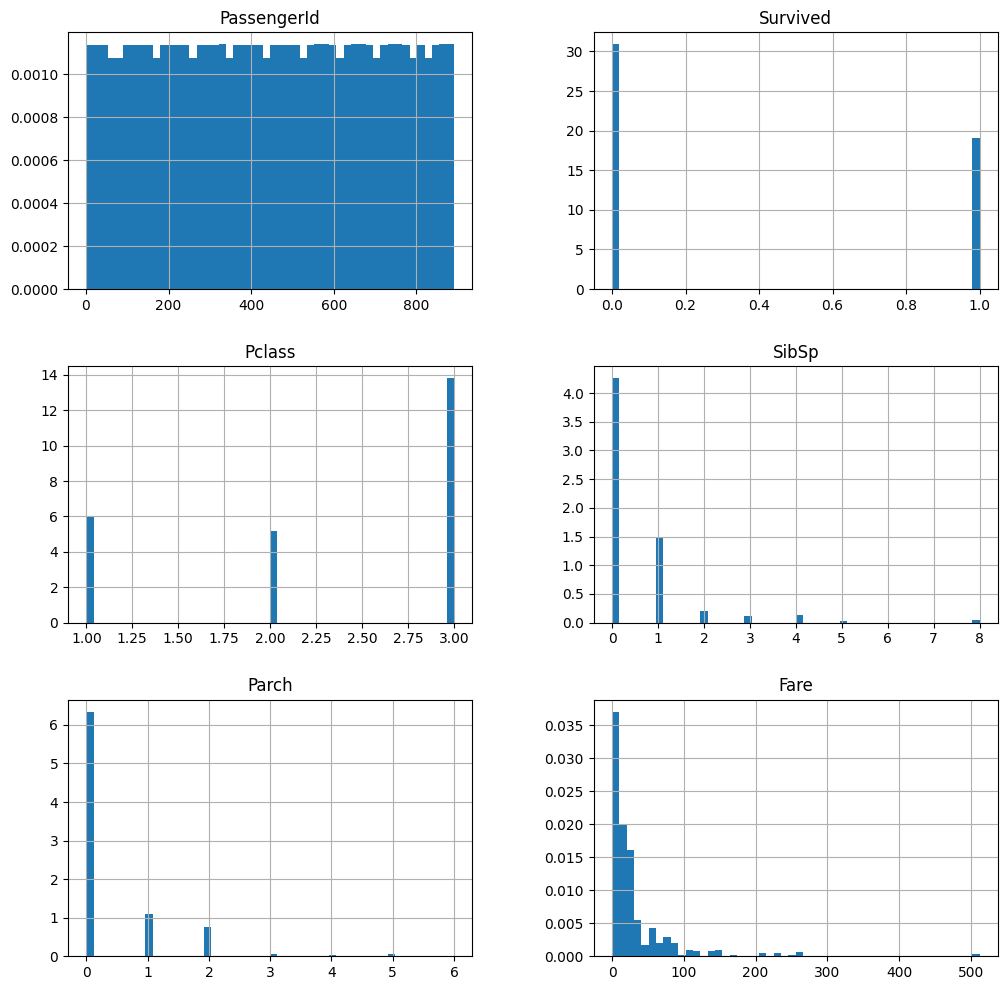

In [9]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()


<Axes: >

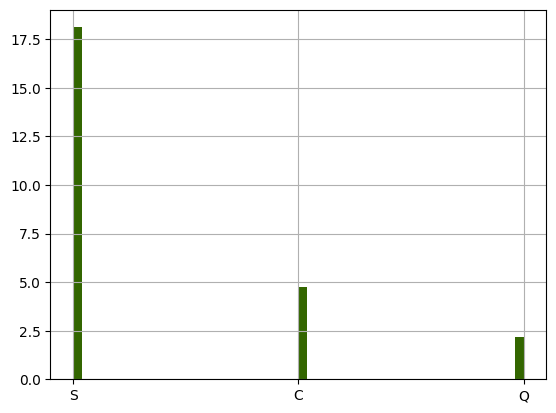

In [10]:
##cca krne bad distribution same rhta toh mtlb missing data was data missing completly at random nd cca apply krna is safe 
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['Embarked'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['Embarked'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

In [12]:
## categiral data m before nd after ratio of each category same rhe 
temp = pd.concat([
            # percentage of observations per category, original data
            df['Embarked'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['Embarked'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
Embarked,,
S,0.722783,0.724409
C,0.188552,0.188976
Q,0.086420,0.086614
